# NPS Cohort & Segment Analysis

## Analysis of Net Promoter Score (NPS) by cohort and user segment.

In [ ]:
!pip -q install duckdb

In [ ]:
## 1. Data Preparation
from google.colab import files
uploaded = files.upload()

Saving nps_survey.csv to nps_survey.csv


In [ ]:
import duckdb, os

print("Files in /content:", os.listdir("/content"))

con = duckdb.connect()

con.execute("""
CREATE OR REPLACE TABLE nps_survey AS
SELECT
  id,
  is_admin,
  score,
  TRY_CAST(created_at AS DATE)  AS created_at,
  TRY_CAST(surveyed_at AS DATE) AS surveyed_at,
  sessions,
  messages
FROM read_csv_auto('/content/nps_survey.csv');
""")

con.execute("SELECT COUNT(*) AS n FROM nps_survey;").fetchdf()

Files in /content: ['.config', 'nps_survey.csv', 'sample_data']


,n
0,20268


In [ ]:
con.execute("""
SELECT
  MIN(created_at) AS min_created,
  MAX(created_at) AS max_created,
  MIN(surveyed_at) AS min_surveyed,
  MAX(surveyed_at) AS max_surveyed
FROM nps_survey;
""").fetchdf()

,min_created,max_created,min_surveyed,max_surveyed
0,2017-01-01,2018-07-31,2017-02-01,2018-08-31


# QUESTION 1: NPS by Signup Cohort (created_at month)

In [ ]:
q1 = """
WITH base AS (
  SELECT
    DATE_TRUNC('month', created_at) AS cohort_month,
    score
  FROM nps_survey
),
agg AS (
  SELECT
    cohort_month,
    COUNT(*) AS surveys,
    SUM(CASE WHEN score IN (9,10) THEN 1 ELSE 0 END) AS promoters,
    SUM(CASE WHEN score BETWEEN 0 AND 6 THEN 1 ELSE 0 END) AS detractors
  FROM base
  GROUP BY 1
)
SELECT
  cohort_month,
  surveys,
  promoters,
  detractors,
  100.0 * (promoters - detractors) / NULLIF(surveys, 0) AS nps
FROM agg
ORDER BY cohort_month;
"""
df_q1 = con.execute(q1).fetchdf()
df_q1

,cohort_month,surveys,promoters,detractors,nps
0,2017-01-01,500,256.0,191.0,13.000000
1,2017-02-01,535,248.0,173.0,14.018692
2,2017-03-01,579,297.0,222.0,12.953368
3,2017-04-01,629,334.0,259.0,11.923688
4,2017-05-01,685,339.0,250.0,12.992701
5,2017-06-01,727,385.0,298.0,11.966988
6,2017-07-01,792,344.0,249.0,11.994949
7,2017-08-01,870,438.0,351.0,10.000000
8,2017-09-01,915,490.0,389.0,11.038251
9,2017-10-01,984,509.0,401.0,10.975610


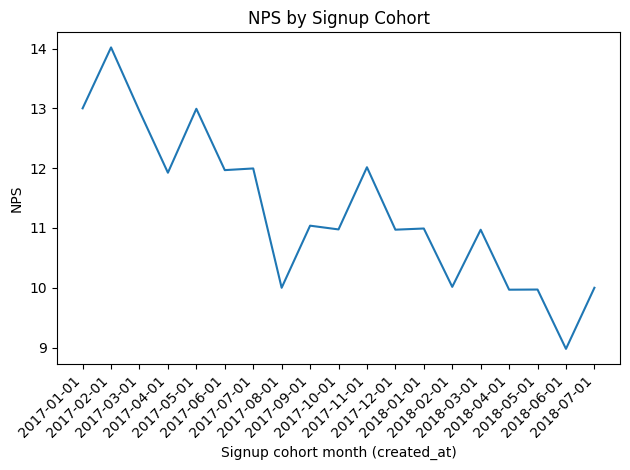

In [ ]:
import matplotlib.pyplot as plt

# Make sure cohort_month is sorted and printable
cohort = df_q1.copy()
cohort["cohort_month"] = cohort["cohort_month"].astype(str)
cohort = cohort.sort_values("cohort_month")

plt.plot(cohort["cohort_month"], cohort["nps"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("NPS")
plt.xlabel("Signup cohort month (created_at)")
plt.title("NPS by Signup Cohort")
plt.tight_layout()
plt.show()

# QUESTION 2:  Monthly NPS Trend by User Segment (surveyed_at month)

In [ ]:
q2 = """
WITH base AS (
  SELECT
    DATE_TRUNC('month', surveyed_at) AS survey_month,
    is_admin,
    score
  FROM nps_survey
),
seg AS (
  SELECT
    survey_month,
    CASE WHEN is_admin THEN 'Admins' ELSE 'Regular' END AS segment,
    COUNT(*) AS surveys,
    SUM(CASE WHEN score IN (9,10) THEN 1 ELSE 0 END) AS promoters,
    SUM(CASE WHEN score BETWEEN 0 AND 6 THEN 1 ELSE 0 END) AS detractors
  FROM base
  GROUP BY 1,2
),
all_users AS (
  SELECT
    survey_month,
    'All users' AS segment,
    COUNT(*) AS surveys,
    SUM(CASE WHEN score IN (9,10) THEN 1 ELSE 0 END) AS promoters,
    SUM(CASE WHEN score BETWEEN 0 AND 6 THEN 1 ELSE 0 END) AS detractors
  FROM base
  GROUP BY 1
)
SELECT
  survey_month,
  segment,
  100.0 * (promoters - detractors) / NULLIF(surveys, 0) AS nps,
  surveys
FROM (
  SELECT * FROM seg
  UNION ALL
  SELECT * FROM all_users
)
ORDER BY survey_month, segment;
"""
df_q2 = con.execute(q2).fetchdf()
df_q2

,survey_month,segment,nps,surveys
0,2017-02-01,Admins,34.800000,250
1,2017-02-01,All users,13.000000,500
2,2017-02-01,Regular,-8.800000,250
3,2017-03-01,Admins,36.121673,263
4,2017-03-01,All users,14.018692,535
5,2017-03-01,Regular,-7.352941,272
6,2017-04-01,Admins,33.818182,275
7,2017-04-01,All users,12.953368,579
8,2017-04-01,Regular,-5.921053,304
9,2017-05-01,Admins,37.024221,289


Visualization 1

<Figure size 1000x400 with 0 Axes>

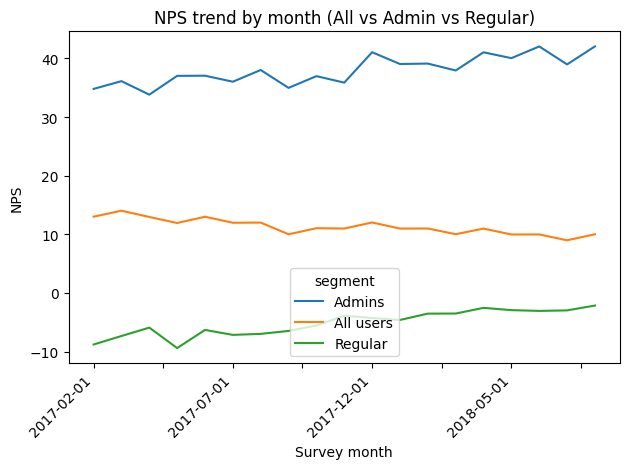

In [ ]:
import matplotlib.pyplot as plt


plot_df = df_q2.copy()
plot_df["survey_month"] = plot_df["survey_month"].astype(str)

pivot = plot_df.pivot(index="survey_month", columns="segment", values="nps").sort_index()
plt.gcf().set_size_inches(10,4)
pivot.plot(kind="line")
plt.xticks(rotation=45, ha="right")
plt.ylabel("NPS")
plt.xlabel("Survey month")
plt.title("NPS trend by month (All vs Admin vs Regular)")
plt.tight_layout()
plt.show()


# QUESTION 3: Check mix shift (% admins over time)

In [ ]:
q3 = """
SELECT
  DATE_TRUNC('month', surveyed_at) AS survey_month,
  COUNT(*) AS total_surveys,
  SUM(CASE WHEN is_admin THEN 1 ELSE 0 END) AS admin_surveys,
  1.0 * SUM(CASE WHEN is_admin THEN 1 ELSE 0 END) / NULLIF(COUNT(*), 0) AS pct_admin
FROM nps_survey
GROUP BY 1
ORDER BY 1;
"""
df_q3 = con.execute(q3).fetchdf()
df_q3

,survey_month,total_surveys,admin_surveys,pct_admin
0,2017-02-01,500,250.0,0.500000
1,2017-03-01,535,263.0,0.491589
2,2017-04-01,579,275.0,0.474957
3,2017-05-01,629,289.0,0.459459
4,2017-06-01,685,305.0,0.445255
5,2017-07-01,727,322.0,0.442916
6,2017-08-01,792,334.0,0.421717
7,2017-09-01,870,346.0,0.397701
8,2017-10-01,915,357.0,0.390164
9,2017-11-01,984,368.0,0.373984


Visualization

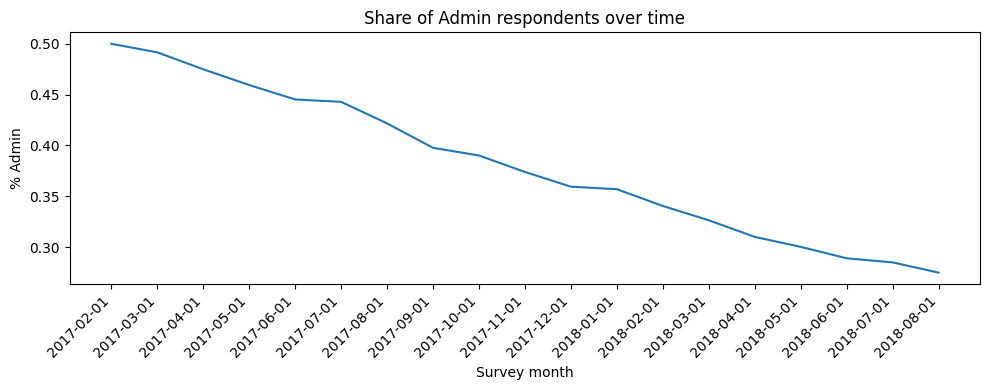

In [ ]:
import matplotlib.pyplot as plt

mix = df_q3.copy()
mix["survey_month"] = mix["survey_month"].astype(str)
plt.gcf().set_size_inches(10,4)
plt.plot(mix["survey_month"], mix["pct_admin"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("% Admin")
plt.xlabel("Survey month")
plt.title("Share of Admin respondents over time")
plt.tight_layout()
plt.show()


In [ ]:
df_q1.to_csv("q1_cohort_nps.csv", index=False)
df_q2.to_csv("q2_monthly_nps_segments.csv", index=False)
df_q3.to_csv("q3_admin_mix_shift.csv", index=False)

from google.colab import files
files.download("q1_cohort_nps.csv")
files.download("q2_monthly_nps_segments.csv")
files.download("q3_admin_mix_shift.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("q1_cohort_nps.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>